In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [3]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/optimizer_data/{env}_{algo}.csv")
            partial_data = partial_data.drop_duplicates(subset=["config_id", "optimizer"], keep="first")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            partial_data = partial_data.set_index("index")
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data).reset_index()

algorithm  optimizer    
dqn        random_search    0.748198
           smac             0.817308
           smac_mf          0.834156
ppo        random_search    0.846066
           smac             0.897037
           smac_mf          0.925893
sac        random_search    0.915163
           smac             1.000000
           smac_mf          0.952699
Name: last_performance, dtype: float64
algorithm  optimizer    
dqn        random_search    0.280684
           smac             0.318653
           smac_mf          0.315582
ppo        random_search    0.230247
           smac             0.234633
           smac_mf          0.104322
sac        random_search    0.132756
           smac             0.000000
           smac_mf          0.047568
Name: last_performance, dtype: float64


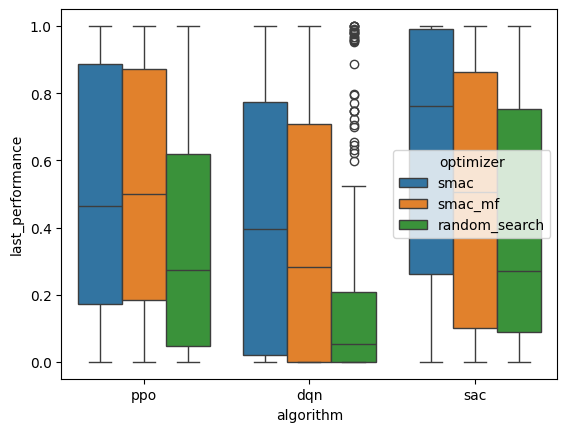

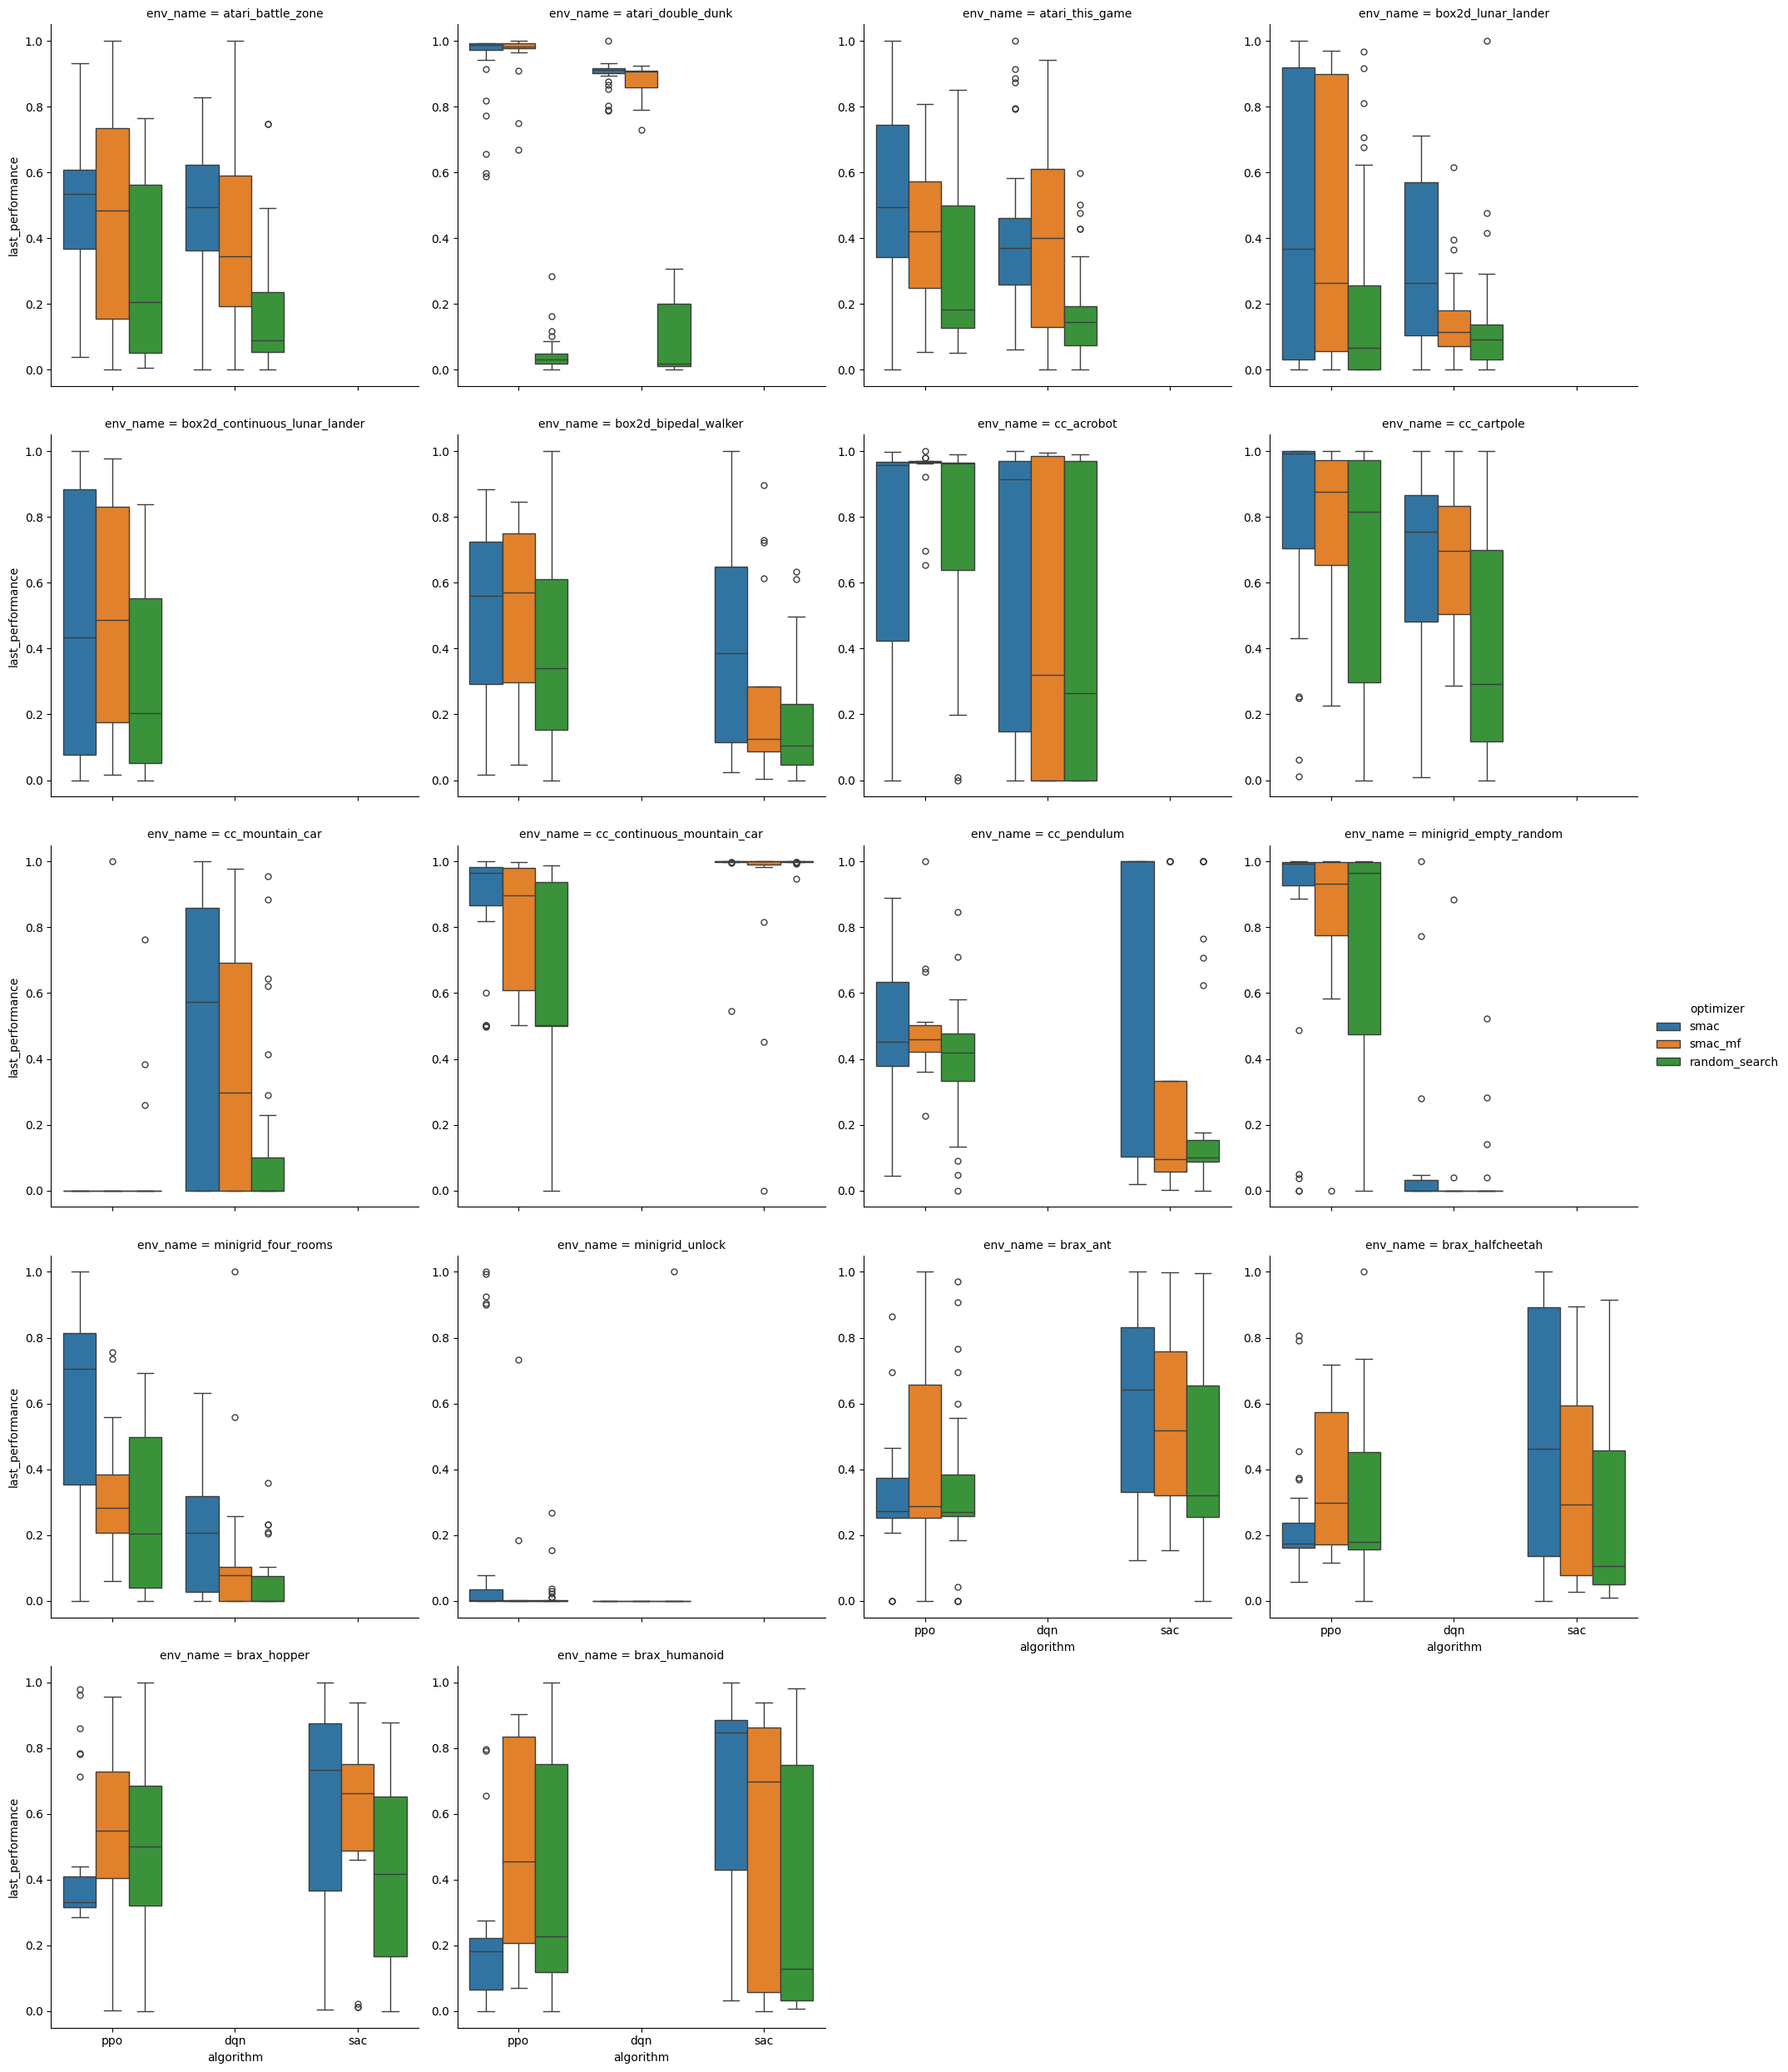

In [10]:
print(data.groupby(["algorithm", "optimizer", "env_name"])["last_performance"].max().groupby(["algorithm", "optimizer"]).mean())
print(data.groupby(["algorithm", "optimizer", "env_name"])["last_performance"].max().groupby(["algorithm", "optimizer"]).std())
sns.boxplot(data=data, y="last_performance", x="algorithm", hue="optimizer")
sns.catplot(data=data, y="last_performance", x="algorithm", hue="optimizer", col="env_name", col_wrap=4, kind="box", sharey=False)

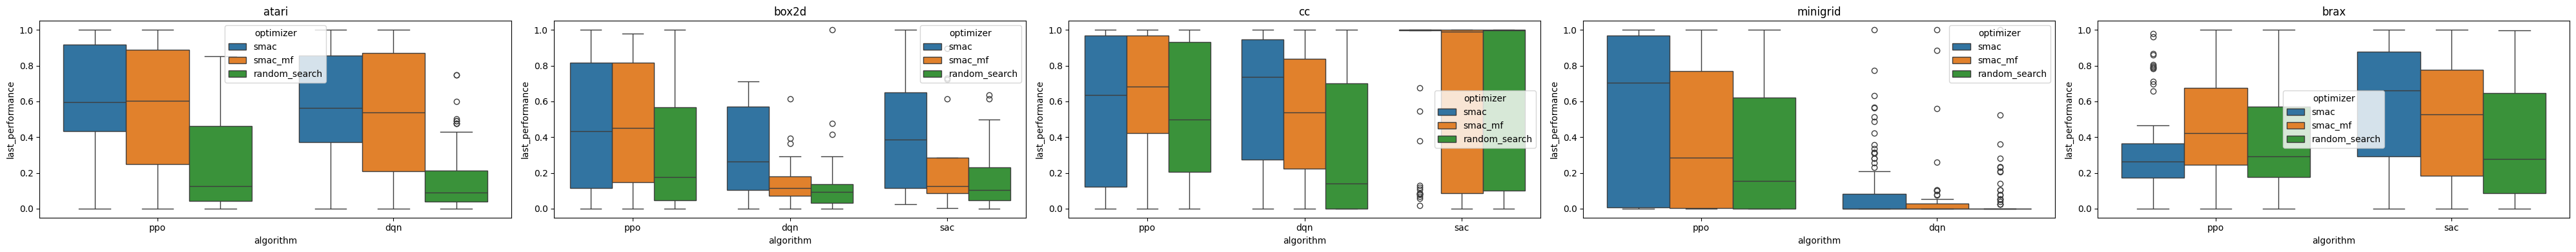

In [26]:
domains = ["atari", "box2d", "cc", "minigrid", "brax"]
fig, ax = plt.subplots(1, len(domains), figsize=(8*len(domains), 4))
for i, domain in enumerate(domains):
    domain_data = data[data["env_name"].str.contains(domain)]
    sns.boxplot(data=domain_data, y="last_performance", x="algorithm", hue="optimizer", ax=ax[i])
    ax[i].set_title(domain)
plt.tight_layout()

<Axes: xlabel='algorithm', ylabel='searchability_gap'>

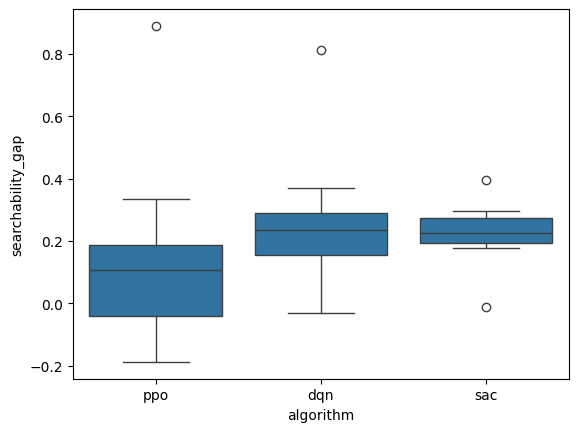

In [29]:
searchability_gaps = []
algorithms = []
environments = []
for env in envs:
    for algo in algos:
        subset = data[(data["env_name"] == env) & (data["algorithm"] == algo)]
        if len(subset) < 2:
                continue
        max_smac_perf = subset[subset["optimizer"] == "smac"]["last_performance"].mean()
        max_rs_perf = subset[subset["optimizer"] == "random_search"]["last_performance"].mean()
        gap = max_smac_perf - max_rs_perf
        searchability_gaps.append(gap)
        algorithms.append(algo)
        environments.append(env)

searchability_df = pd.DataFrame({
    "environment": environments,
    "algorithm": algorithms,
    "searchability_gap": searchability_gaps
})
sns.boxplot(data=searchability_df, y="searchability_gap", x="algorithm")

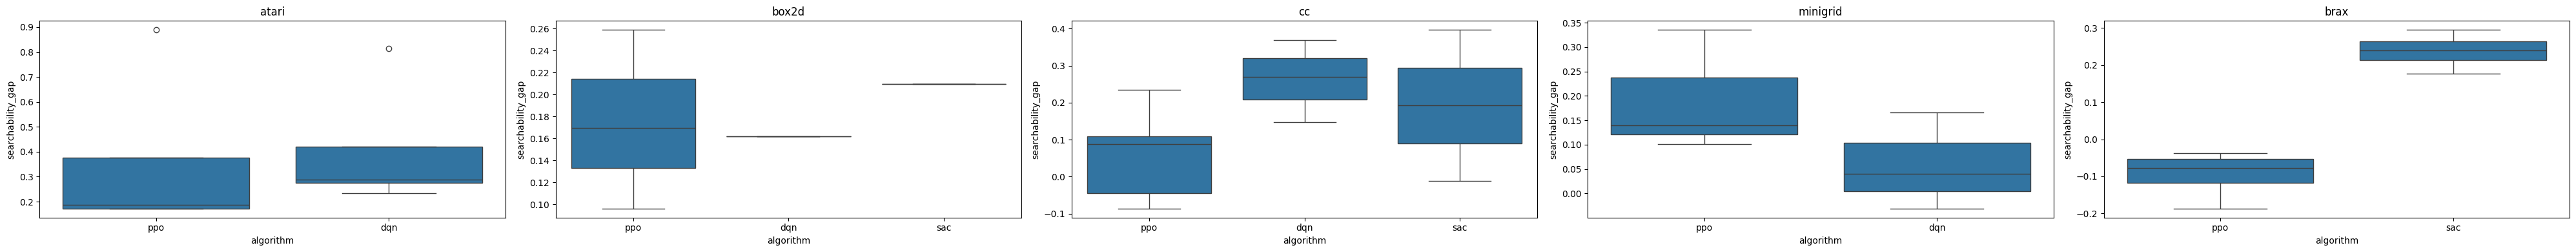

In [31]:
domains = ["atari", "box2d", "cc", "minigrid", "brax"]
fig, ax = plt.subplots(1, len(domains), figsize=(8*len(domains), 4))
for i, domain in enumerate(domains):
    domain_data = searchability_df[searchability_df["environment"].str.contains(domain)]
    sns.boxplot(data=domain_data, y="searchability_gap", x="algorithm", ax=ax[i])
    ax[i].set_title(domain)
plt.tight_layout()